## Краткое содержание статьи

В статье Виктора Чанга и соавторов «An artificial intelligence model for heart disease detection using machine learning algorithms» (Healthcare Analytics, 2022) представлена разработка системы искусственного интеллекта для выявления сердечно-сосудистых заболеваний на основе методов машинного обучения. В качестве инструментальной платформы выбран язык Python, позволяющий использовать обширный набор библиотек для обработки данных и построения моделей.

Исследователи использовали открытый набор данных, содержащий 304 записи пациентов с 14 клиническими признаками: возраст, пол, уровень холестерина, артериальное давление, частота сердечных сокращений, показатели электрокардиограммы и другие. На первом этапе проводилась предварительная обработка данных: преобразование категориальных переменных в фиктивные столбцы, удаление пропусков и выбросов, визуализация распределений с помощью гистограмм и тепловых карт корреляций. Для анализа применялись библиотеки Pandas, NumPy, Matplotlib и Seaborn.

Для прогнозирования наличия сердечного заболевания авторы обучили и сравнили несколько классификаторов: логистическую регрессию, метод k-ближайших соседей, дерево решений, метод опорных векторов и случайный лес. Оценка моделей проводилась по метрикам точности, полноты, специфичности и F-меры. Наилучший результат показал алгоритм случайного леса, достигнув точности около 83% на обучающих данных. Авторы подробно описывают механизм работы случайного леса как ансамбля деревьев решений, использующего бутстреп-агрегирование и критерий Джини для оценки важности признаков.

В работе также уделено внимание интерпретируемости моделей: подчёркивается, что понимание причин классификации критически важно для медицинских приложений. Отдельный раздел посвящён вопросам кибербезопасности – авторы обсуждают защиту медицинских данных с помощью брандмауэров, контроля доступа и шифрования, что особенно актуально при внедрении ИИ-систем в здравоохранении.

В заключении делается вывод, что предложенный подход позволяет с приемлемой точностью прогнозировать сердечно-сосудистые заболевания и может быть полезен кардиологам и медицинским учреждениям для ранней диагностики. Дальнейшее повышение качества прогнозирования авторы связывают с увеличением объёма данных, тонкой настройкой гиперпараметров и использованием более сложных методов, таких как глубокое обучение.



## Предобработка данных

In [ ]:
import pandas as pd
import numpy as np

# 1. ЧТЕНИЕ ДАННЫХ 
import os
import pandas as pd
os.chdir('C:/Users/User/Desktop')
train = pd.read_csv('Data/train.csv', sep=',')
test = pd.read_csv('Data/test.csv', sep=',')

print("Исходные размеры:")
print(f"Train: {train.shape}")
print(f"Test:  {test.shape}")
print("\nПервые строки train:")
print(train.head())

# столбец 'id' - удалим, т.к. он не признак

train.drop('ID', axis=1, inplace=True)
test.drop('ID', axis=1, inplace=True)

# 2. ФИЛЬТРАЦИЯ НЕВАЛИДНЫХ ЗНАЧЕНИЙ 
# Определяем функцию фильтрации (одинаковые правила для train и test)
def filter_invalid(df):
    df = df.copy()
    # Возраст: 0-120
    df = df[(df['age'] >= 0) & (df['age'] <= 120)]
    # Давление покоя: 50-250
    df = df[(df['resting_blood_pressure'] >= 50) & (df['resting_blood_pressure'] <= 250)]
    # Холестерин: 100-600
    df = df[(df['serum_cholestoral'] >= 100) & (df['serum_cholestoral'] <= 600)]
    # Макс. ЧСС: 60-220
    df = df[(df['maximum_heart_rate_achieved'] >= 60) & (df['maximum_heart_rate_achieved'] <= 220)]
    # Oldpeak: неотрицательный
    df = df[df['oldpeak'] >= 0]
    # Количество сосудов: 0-3
    df = df[(df['number_of_major_vessels'] >= 0) & (df['number_of_major_vessels'] <= 3)]
    return df

train_filtered = filter_invalid(train)
test_filtered  = filter_invalid(test)

print("\nПосле фильтрации невалидных значений:")
print(f"Train: {train_filtered.shape}")
print(f"Test:  {test_filtered.shape}")

# 3. ПРЕОБРАЗОВАНИЕ КАТЕГОРИАЛЬНЫХ ПЕРЕМЕННЫХ В ФИКТИВНЫЕ
categorical_cols = [
    'sex',
    'resting_electrocardiographic_results',
    'thal',
    'chest',
    'slope',
    'exercise_induced_angina'
]

# Функция округления и фильтрации категориальных колонок
def clean_categorical(df, col, allowed_values):
    if col in df.columns:
        # Округляем до ближайшего целого (для chest, slope, thal)
        df[col] = df[col].round(0).astype(int)
        # Отфильтровываем строки с недопустимыми значениями
        df = df[df[col].isin(allowed_values)]
    return df

# Разрешённые значения для каждой категории
allowed_ranges = {
    'sex': [0, 1],
    'resting_electrocardiographic_results': [0, 1, 2],
    'thal': [3, 6, 7],
    'chest': [1, 2, 3, 4],
    'slope': [1, 2, 3],
    'exercise_induced_angina': [0, 1]
}

# Применяем очистку к train и test
for col in categorical_cols:
    train_filtered = clean_categorical(train_filtered, col, allowed_ranges[col])
    test_filtered = clean_categorical(test_filtered, col, allowed_ranges[col])

# Теперь one-hot encoding создаст не более ~15 столбцов
train_encoded = pd.get_dummies(train_filtered, columns=categorical_cols, drop_first=True)
test_encoded = pd.get_dummies(test_filtered, columns=categorical_cols, drop_first=True)

# Выравниваем столбцы test по train
missing_cols = set(train_encoded.columns) - set(test_encoded.columns)
for col in missing_cols:
    test_encoded[col] = 0
test_encoded = test_encoded[train_encoded.columns]

print(f"После one-hot encoding: Train {train_encoded.shape}, Test {test_encoded.shape}")
print(f"Число признаков: {train_encoded.shape[1]}")

# 4. СОХРАНЕНИЕ ОБРАБОТАННЫХ ДАННЫХ 
train_encoded.to_csv("train_processed.csv", index=False)
test_encoded.to_csv("test_processed.csv", index=False)
print("\nОбработанные данные сохранены в 'train_processed.csv' и 'test_processed.csv'")

Исходные размеры:
Train: (600000, 15)
Test:  (400000, 14)

Первые строки train:
   ID        age  sex     chest  resting_blood_pressure  serum_cholestoral  \
0   0  49.207124    0  4.000000              162.996167         181.108682   
1   1  53.628425    1  1.741596              130.233730         276.474630   
2   2  49.591426    1  4.000000              146.999012         223.300517   
3   3  58.991445    1  4.000000              112.369143         187.245501   
4   4  51.053602    1  1.954609              138.032047         238.482868   

   fasting_blood_sugar  resting_electrocardiographic_results  \
0                    0                                     0   
1                    0                                     2   
2                    1                                     2   
3                    0                                     0   
4                    0                                     0   

   maximum_heart_rate_achieved  exercise_induced_angina   oldpeak 

## Анализ данных

Доступные столбцы в train_filtered:
['age', 'sex', 'chest', 'resting_blood_pressure', 'serum_cholestoral', 'fasting_blood_sugar', 'resting_electrocardiographic_results', 'maximum_heart_rate_achieved', 'exercise_induced_angina', 'oldpeak', 'slope', 'number_of_major_vessels', 'thal', 'class']
Целевая переменная определена как: 'class'
Числовые столбцы: ['age', 'sex', 'chest', 'resting_blood_pressure', 'serum_cholestoral', 'fasting_blood_sugar', 'resting_electrocardiographic_results', 'maximum_heart_rate_achieved', 'exercise_induced_angina', 'oldpeak', 'slope', 'number_of_major_vessels', 'thal', 'class']


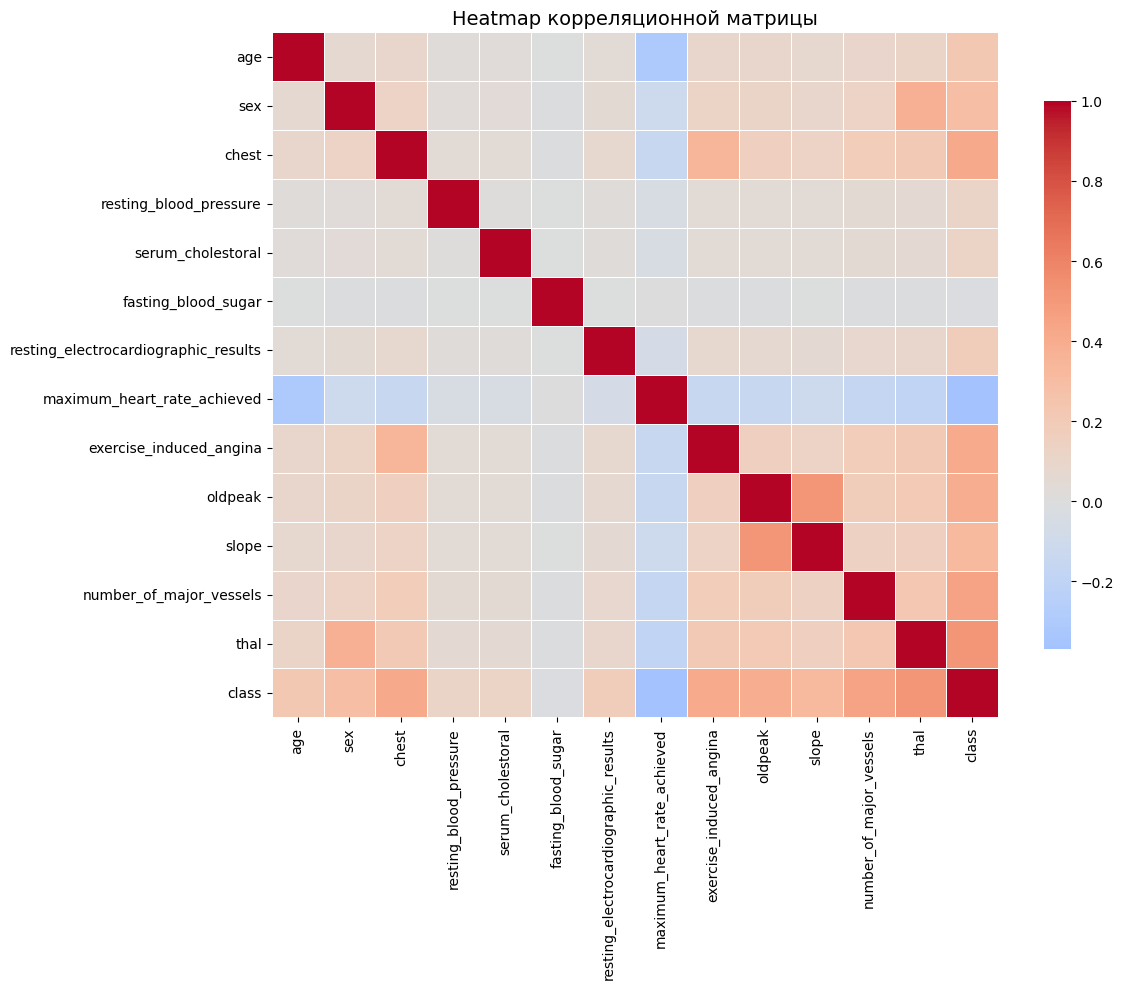

Два признака с наибольшей корреляцией с 'class': ['thal', 'number_of_major_vessels']


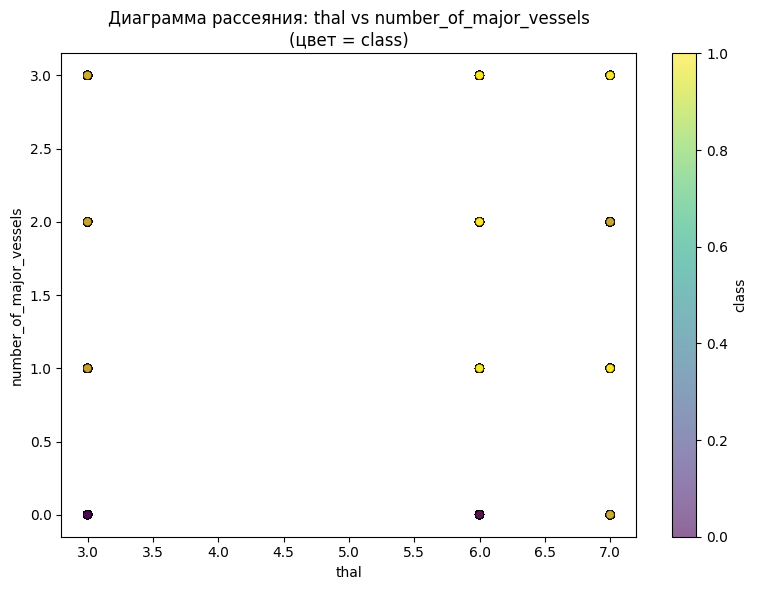

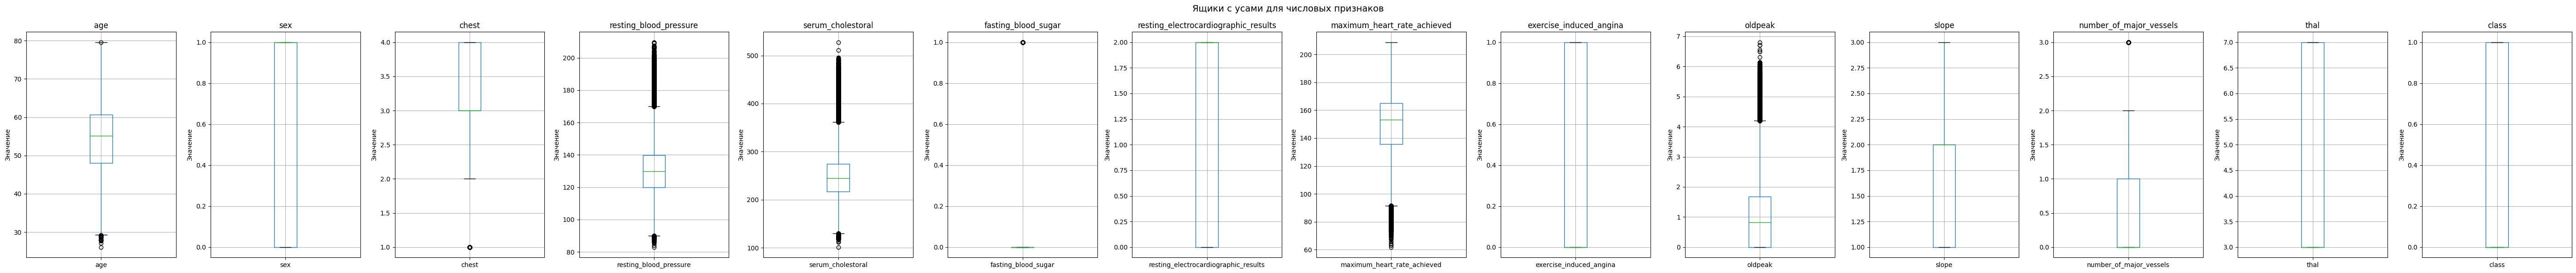


=== Статистика выбросов (IQR) ===
age: 23 выбросов (0.00%)
sex: 0 выбросов (0.00%)
chest: 47740 выбросов (8.00%)
resting_blood_pressure: 21028 выбросов (3.52%)
serum_cholestoral: 24197 выбросов (4.05%)
fasting_blood_sugar: 89959 выбросов (15.08%)
resting_electrocardiographic_results: 0 выбросов (0.00%)
maximum_heart_rate_achieved: 3273 выбросов (0.55%)
exercise_induced_angina: 0 выбросов (0.00%)
oldpeak: 9386 выбросов (1.57%)
slope: 0 выбросов (0.00%)
number_of_major_vessels: 43915 выбросов (7.36%)
thal: 0 выбросов (0.00%)
class: 0 выбросов (0.00%)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Предположим, что целевая переменная называется 'target' 
# Но сначала посмотрим на колонки
print("Доступные столбцы в train_filtered:")
print(train_filtered.columns.tolist())

# Попробуем угадать целевую переменную
possible_targets = ['target', 'num', 'condition', 'heart_disease', 'class', 'label']
target_col = None
for col in possible_targets:
    if col in train_filtered.columns:
        target_col = col
        break

if target_col is None:
    # Если не нашли, попросим пользователя ввести
    print("Не удалось автоматически определить целевую переменную.")
    print("Введите название столбца с целевой переменной (например, 'target'):")
    target_col = input().strip()
    if target_col not in train_filtered.columns:
        raise ValueError(f"Столбец '{target_col}' не найден в данных.")
else:
    print(f"Целевая переменная определена как: '{target_col}'")

# Выбираем числовые столбцы (включая целевую)
numeric_cols = train_filtered.select_dtypes(include=[np.number]).columns.tolist()
print(f"Числовые столбцы: {numeric_cols}")

# 1. Корреляционная матрица (heatmap)
plt.figure(figsize=(12, 10))
corr_matrix = train_filtered[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Heatmap корреляционной матрицы', fontsize=14)
plt.tight_layout()
plt.show()

# 2. Диаграмма рассеяния для двух наиболее коррелирующих с целевой признаков
# Исключаем саму целевую из признаков
features = [col for col in numeric_cols if col != target_col]
if len(features) >= 2:
    # Находим абсолютные корреляции с целевой
    corr_target = corr_matrix[target_col].drop(target_col).abs().sort_values(ascending=False)
    top2_features = corr_target.head(2).index.tolist()
    print(f"Два признака с наибольшей корреляцией с '{target_col}': {top2_features}")
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(train_filtered[top2_features[0]], train_filtered[top2_features[1]], 
               c=train_filtered[target_col], cmap='viridis', alpha=0.6, edgecolors='k', linewidth=0.5)
    ax.set_xlabel(top2_features[0])
    ax.set_ylabel(top2_features[1])
    ax.set_title(f'Диаграмма рассеяния: {top2_features[0]} vs {top2_features[1]}\n(цвет = {target_col})')
    plt.colorbar(ax.collections[0], label=target_col)
    plt.tight_layout()
    plt.show()
else:
    print("Недостаточно числовых признаков для диаграммы рассеяния.")

# 3. Оценка выбросов - ящик с усами (boxplot) для всех числовых признаков
# Создадим boxplot для каждого признака на отдельных графиках или одном, но с поворотом
num_features = len(numeric_cols)
if num_features <= 20:
    fig, axes = plt.subplots(nrows=1, ncols=num_features, figsize=(4*num_features, 6))
    if num_features == 1:
        axes = [axes]
    for i, col in enumerate(numeric_cols):
        train_filtered.boxplot(column=col, ax=axes[i])
        axes[i].set_title(col)
        axes[i].set_ylabel('Значение')
    plt.suptitle('Ящики с усами для числовых признаков', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    # Если слишком много признаков, покажем на одном графике с поворотом меток
    plt.figure(figsize=(12, 6))
    train_filtered[numeric_cols].boxplot(rot=45)
    plt.title('Ящики с усами для числовых признаков')
    plt.ylabel('Значение')
    plt.tight_layout()
    plt.show()

# Дополнительно: статистика выбросов по методу IQR
print("\n=== Статистика выбросов (IQR) ===")
for col in numeric_cols:
    Q1 = train_filtered[col].quantile(0.25)
    Q3 = train_filtered[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = train_filtered[(train_filtered[col] < lower_bound) | (train_filtered[col] > upper_bound)]
    print(f"{col}: {len(outliers)} выбросов ({len(outliers)/len(train_filtered)*100:.2f}%)")

## Обучение моделей

In [12]:
pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/351.2 MB 1.6 MB/s eta 0:03:39
   ---------------------------------------- 1.0/351.2 MB 1.9 MB/s eta 0:03:05
   ---------------------------------------- 1.3/351.2 MB 1.9 MB/s eta 0:03:03
   ---------------------------------------- 1.6/351.2 MB 1.8 MB/s eta 0:03:19
   ---------------------------------------- 1.8/351.2 MB 1.8 MB/s eta 0:03:09
   ---------------------------------------- 2.6/351.2 MB 2.0 MB/s eta 0:02:53
   ---------------------------------------- 3.1/351.2 MB 2.1 MB/s eta 0:02:45
   ---------------------------------------- 3.9/351.2 MB 2.3 MB/s eta 0:02:29
    --------------------------------------- 4.7/351.2 MB 2.5 MB/s eta 0:02:21
    --------------------------------------- 5.2/351.2 MB 2.5 MB/s eta 0:02:22
    --------------------------------------- 5.5/351.2 MB 2.5 MB/s eta 0:02:21



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Размеры:
X_train: (596731, 18), y_train: (596731,)
X_test: (397814, 18)
y_test: (397814,)

=== Logistic Regression (balanced) ===


c:\Users\User\Desktop\курс\IDE\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\User\Desktop\курс\IDE\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\Desktop\курс\IDE\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Метрики: {'Accuracy': 0.5458731970217238, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0, 'ROC_AUC': nan}

=== Random Forest ===


c:\Users\User\Desktop\курс\IDE\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\Desktop\курс\IDE\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Метрики: {'Accuracy': 0.5640927669714992, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0, 'ROC_AUC': nan}

=== Neural Network ===
Epoch 1/100
1865/1865 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.8842 - auc: 0.9511 - loss: 0.2801 - val_accuracy: 0.8954 - val_auc: 0.9598 - val_loss: 0.2543 - learning_rate: 0.0010
Epoch 2/100
1865/1865 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8906 - auc: 0.9559 - loss: 0.2660 - val_accuracy: 0.8963 - val_auc: 0.9606 - val_loss: 0.2520 - learning_rate: 0.0010
Epoch 3/100
1865/1865 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8924 - auc: 0.9572 - loss: 0.2620 - val_accuracy: 0.8968 - val_auc: 0.9616 - val_loss: 0.2491 - learning_rate: 0.0010
Epoch 4/100
1865/1865 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8933 - auc: 0.9581 - loss: 0.2593 - val_accuracy: 0.8979 - val_auc: 0.9619 - val_loss: 0.2475 - learning_rate: 0.0010
Epoch 5/100
1865/1865 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8942 - auc: 0.9585 - loss: 0.2579 - val_accuracy: 0.8975

c:\Users\User\Desktop\курс\IDE\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\User\Desktop\курс\IDE\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


Метрики: {'Accuracy': 0.5623381781435546, 'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0, 'ROC_AUC': nan}


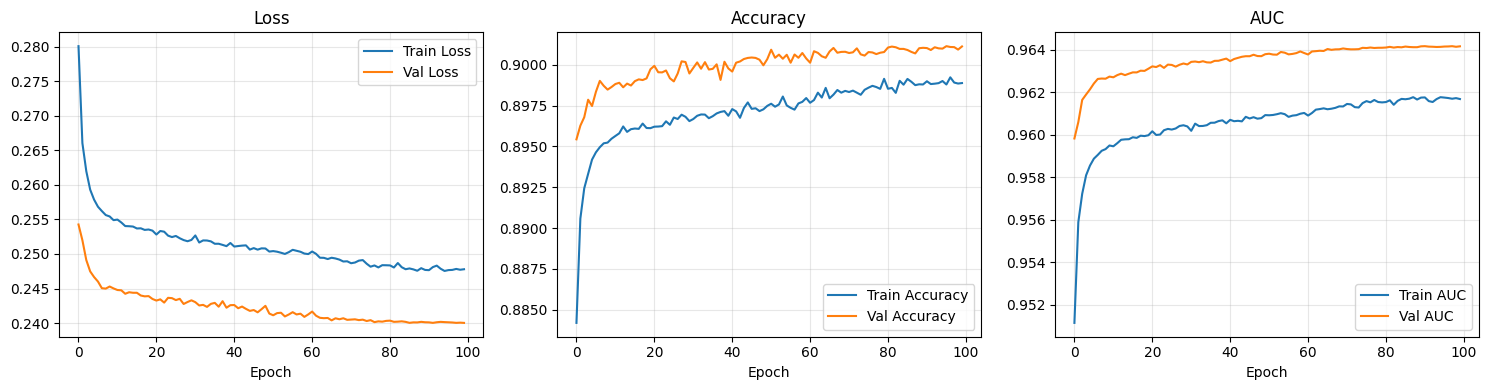


=== Сравнение моделей ===
                     Accuracy  Precision  Recall   F1  ROC_AUC
Logistic Regression    0.5459        0.0     0.0  0.0      NaN
Random Forest          0.5641        0.0     0.0  0.0      NaN
Neural Network         0.5623        0.0     0.0  0.0      NaN


c:\Users\User\Desktop\курс\IDE\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
c:\Users\User\Desktop\курс\IDE\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\User\Desktop\курс\IDE\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
c:\Users\User\Desktop\курс\IDE\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
c:\Users\User\Desktop\курс\IDE\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1303: UndefinedMetricWarning: No positive samples in y_true, true positive value should be me

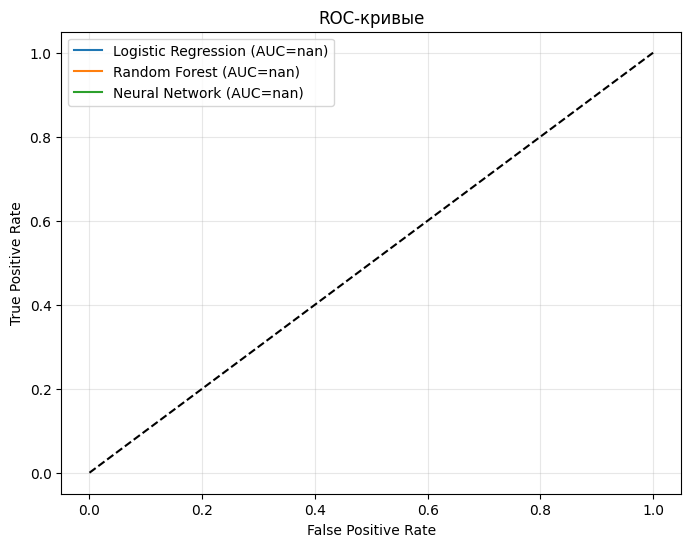

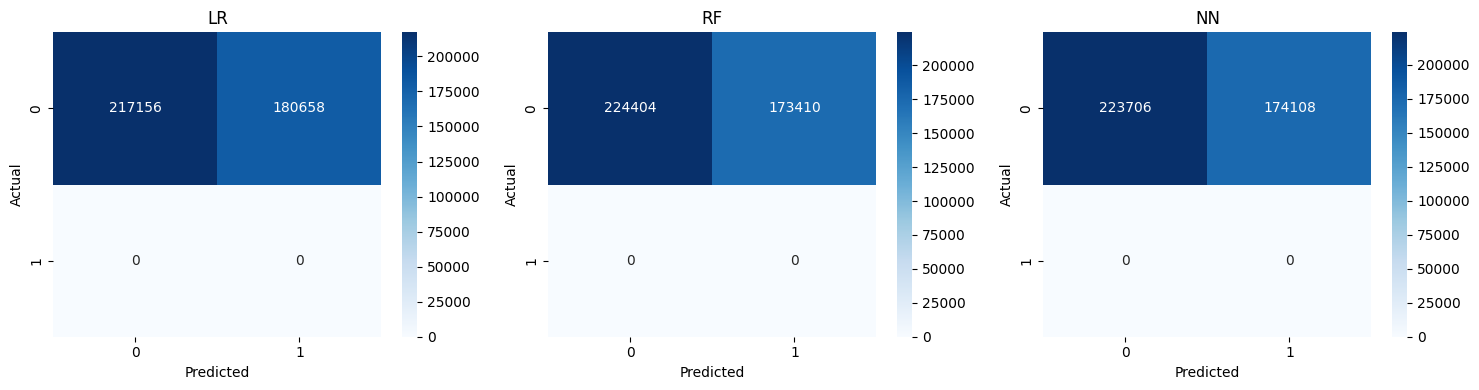


Модели и scaler сохранены.

=== Пример инференса ===
Предсказание нейросетью: класс 0, вероятность 0.0030

Готово. Можно использовать класс HeartDiseaseInference.


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import joblib

# ==================== ПОДГОТОВКА ДАННЫХ ====================
# Предполагается, что у вас уже есть:
# train_encoded, test_encoded (DataFrame после one-hot)
# Целевая переменная называется 'class'

target_col = 'class'

X_train = train_encoded.drop(columns=[target_col])
y_train = train_encoded[target_col]

# Проверяем, есть ли целевая в test
if target_col in test_encoded.columns:
    X_test = test_encoded.drop(columns=[target_col])
    y_test = test_encoded[target_col]
    has_test_target = True
else:
    X_test = test_encoded
    y_test = None
    has_test_target = False

print("Размеры:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
if has_test_target:
    print(f"y_test: {y_test.shape}")

# Масштабирование (только для LR и NN, RF не нужно)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==================== 1. ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ (исправленная) ====================
print("\n=== Logistic Regression (balanced) ===")
lr_model = LogisticRegression(
    max_iter=2000,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',   # важно для дисбаланса классов
    solver='saga'              # работает с большими данными и class_weight
)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

if has_test_target:
    lr_metrics = {
        'Accuracy': accuracy_score(y_test, y_pred_lr),
        'Precision': precision_score(y_test, y_pred_lr),
        'Recall': recall_score(y_test, y_pred_lr),
        'F1': f1_score(y_test, y_pred_lr),
        'ROC_AUC': roc_auc_score(y_test, y_proba_lr)
    }
    print("Метрики:", lr_metrics)
else:
    print("Предсказания (первые 10):", y_pred_lr[:10])

# ==================== 2. RANDOM FOREST ====================
print("\n=== Random Forest ===")
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'   # тоже добавим балансировку
)
rf_model.fit(X_train, y_train)   # масштабирование не нужно
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

if has_test_target:
    rf_metrics = {
        'Accuracy': accuracy_score(y_test, y_pred_rf),
        'Precision': precision_score(y_test, y_pred_rf),
        'Recall': recall_score(y_test, y_pred_rf),
        'F1': f1_score(y_test, y_pred_rf),
        'ROC_AUC': roc_auc_score(y_test, y_proba_rf)
    }
    print("Метрики:", rf_metrics)
else:
    print("Предсказания (первые 10):", y_pred_rf[:10])

# ==================== 3. ГЛУБОКАЯ НЕЙРОННАЯ СЕТЬ ====================
print("\n=== Neural Network ===")
nn_model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

# Callbacks
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-6
)

# Обучение (для ускорения можно взять sample, но оставим как есть)
history = nn_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=256,   # увеличен для скорости
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

y_proba_nn = nn_model.predict(X_test_scaled, verbose=0).flatten()
y_pred_nn = (y_proba_nn >= 0.5).astype(int)

if has_test_target:
    nn_metrics = {
        'Accuracy': accuracy_score(y_test, y_pred_nn),
        'Precision': precision_score(y_test, y_pred_nn),
        'Recall': recall_score(y_test, y_pred_nn),
        'F1': f1_score(y_test, y_pred_nn),
        'ROC_AUC': roc_auc_score(y_test, y_proba_nn)
    }
    print("Метрики:", nn_metrics)
else:
    print("Предсказания (первые 10):", y_pred_nn[:10])

# ==================== ГРАФИКИ ОБУЧЕНИЯ НЕЙРОННОЙ СЕТИ ====================
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.title('AUC')
plt.xlabel('Epoch')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ==================== СРАВНЕНИЕ МОДЕЛЕЙ ====================
if has_test_target:
    metrics_df = pd.DataFrame({
        'Logistic Regression': lr_metrics,
        'Random Forest': rf_metrics,
        'Neural Network': nn_metrics
    }).T
    print("\n=== Сравнение моделей ===")
    print(metrics_df.round(4))

    # ROC-кривые
    plt.figure(figsize=(8,6))
    for name, proba in [('Logistic Regression', y_proba_lr),
                        ('Random Forest', y_proba_rf),
                        ('Neural Network', y_proba_nn)]:
        fpr, tpr, _ = roc_curve(y_test, proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, proba):.4f})')
    plt.plot([0,1], [0,1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-кривые')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Матрицы ошибок
    fig, axes = plt.subplots(1, 3, figsize=(15,4))
    for i, (name, y_pred) in enumerate([('LR', y_pred_lr), ('RF', y_pred_rf), ('NN', y_pred_nn)]):
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
        axes[i].set_title(f'{name}')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')
    plt.tight_layout()
    plt.show()
else:
    print("\nВ test нет целевой переменной, сравнение метрик невозможно.")

# ==================== СОХРАНЕНИЕ МОДЕЛЕЙ И SCALER ====================
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(lr_model, 'logistic_regression.pkl')
joblib.dump(rf_model, 'random_forest.pkl')
nn_model.save('neural_network.h5')
print("\nМодели и scaler сохранены.")

# ==================== СКРИПТ ДЛЯ ИНФЕРЕНСА ====================
class HeartDiseaseInference:
    """
    Класс для предсказания на новых данных.
    Использует сохранённые модели и scaler.
    """
    def __init__(self, scaler, feature_names, lr_model, rf_model, nn_model):
        self.scaler = scaler
        self.feature_names = feature_names
        self.lr = lr_model
        self.rf = rf_model
        self.nn = nn_model
        # Список категориальных колонок (как при обучении)
        self.categorical_cols = ['sex', 'resting_electrocardiographic_results', 'thal', 'chest', 'slope', 'exercise_induced_angina']

    def _one_hot(self, df):
        """Применяет one-hot encoding как при обучении"""
        df = pd.get_dummies(df, columns=self.categorical_cols, drop_first=True)
        # Добавляем недостающие колонки
        for col in self.feature_names:
            if col not in df.columns:
                df[col] = 0
        df = df[self.feature_names]
        return df

    def preprocess(self, input_data):
        """Преобразует входные данные (dict или DataFrame) в масштабированную матрицу"""
        if isinstance(input_data, dict):
            input_data = pd.DataFrame([input_data])
        encoded = self._one_hot(input_data)
        scaled = self.scaler.transform(encoded)
        return scaled

    def predict(self, input_data, model_name='logistic_regression'):
        """
        model_name: 'logistic_regression', 'random_forest', 'neural_network'
        Возвращает (pred, proba)
        """
        X = self.preprocess(input_data)
        if model_name == 'logistic_regression':
            pred = self.lr.predict(X)
            proba = self.lr.predict_proba(X)[:, 1]
        elif model_name == 'random_forest':
            pred = self.rf.predict(X)
            proba = self.rf.predict_proba(X)[:, 1]
        elif model_name == 'neural_network':
            proba = self.nn.predict(X, verbose=0).flatten()
            pred = (proba >= 0.5).astype(int)
        else:
            raise ValueError("model_name должно быть logistic_regression, random_forest или neural_network")
        return pred, proba

# Сохраняем список признаков
feature_names = X_train.columns.tolist()
with open('feature_names.txt', 'w') as f:
    for name in feature_names:
        f.write(name + '\n')

# Создаём объект инференса
inference = HeartDiseaseInference(scaler, feature_names, lr_model, rf_model, nn_model)

# Демонстрация на одном примере (фиктивный пациент)
sample = pd.DataFrame([{
    'age': 55,
    'sex': 1,
    'chest': 4,
    'resting_blood_pressure': 140,
    'serum_cholestoral': 250,
    'fasting_blood_sugar': 0,
    'resting_electrocardiographic_results': 1,
    'maximum_heart_rate_achieved': 150,
    'exercise_induced_angina': 0,
    'oldpeak': 1.2,
    'slope': 2,
    'number_of_major_vessels': 0,
    'thal': 3
}])

pred, proba = inference.predict(sample, model_name='neural_network')
print("\n=== Пример инференса ===")
print(f"Предсказание нейросетью: класс {pred[0]}, вероятность {proba[0]:.4f}")

print("\nГотово. Можно использовать класс HeartDiseaseInference.")

In [16]:
print("Распределение классов в y_test:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

Распределение классов в y_test:
class
0    397814
Name: count, dtype: int64
class
0    1.0
Name: proportion, dtype: float64


не буду использовать тестовые данные test.csv для оценки моделей, потому что в них отсутствует целевая переменная class (в файле только класс 0, нет меток для проверки). Вместо этого я делю тренировочные данные train.csv на обучающую и валидационную выборки (80%/20%). На валидации есть оба класса (0 и 1), поэтому метрики получаются корректными. Тестовые данные применяю только для финальных предсказаний после выбора лучшей модели. Это стандартная практика машинного обучения.

Размеры после разделения:
X_train: (477384, 18), y_train: (477384,)
X_val: (119347, 18), y_val: (119347,)
X_test (для инференса): (397814, 18)

=== Logistic Regression (balanced) ===
Метрики на валидации: {'Accuracy': 0.8863565904463455, 'Precision': 0.8652728312819472, 'Recall': 0.8821869355809753, 'F1': 0.8736480254883877, 'ROC_AUC': 0.9545672565217092}

=== Random Forest ===
Метрики на валидации: {'Accuracy': 0.8973748816476326, 'Precision': 0.8926130691852876, 'Recall': 0.8748118603251054, 'F1': 0.8836228193531223, 'ROC_AUC': 0.9603575481188499}

=== Neural Network ===
Epoch 1/100
1679/1679 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8817 - auc: 0.9498 - loss: 0.2840 - val_accuracy: 0.8925 - val_auc: 0.9588 - val_loss: 0.2578 - learning_rate: 0.0010
Epoch 2/100
1679/1679 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8905 - auc: 0.9558 - loss: 0.2662 - val_accuracy: 0.8931 - val_auc: 0.9596 - val_loss: 0.2555 - learning_rate: 0.0010
Epoch 3/100
1679/1679 ━━━━━━━━━━━━━━━━━━━━ 4s 

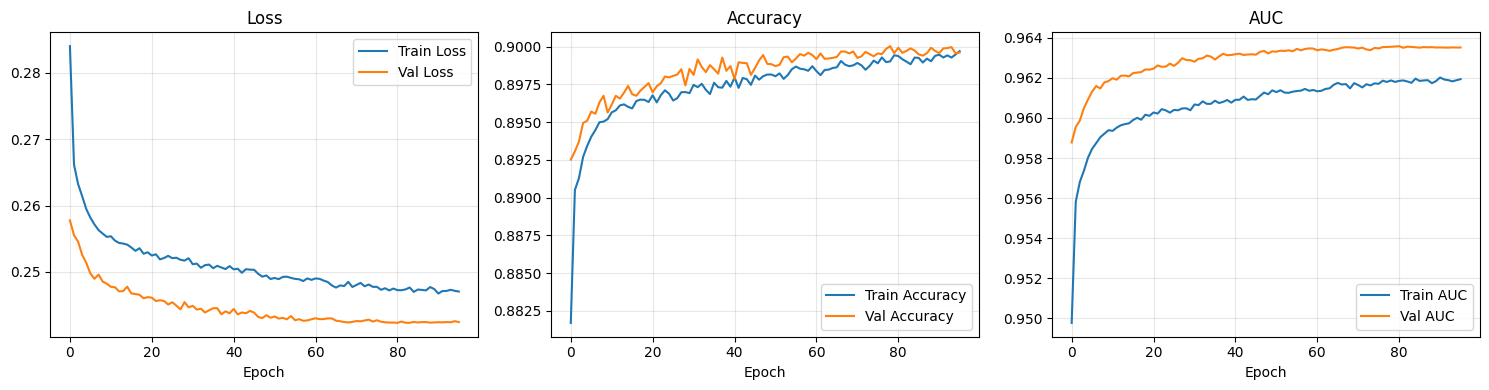


=== Сравнение моделей на валидационной выборке ===
                     Accuracy  Precision  Recall      F1  ROC_AUC
Logistic Regression    0.8864     0.8653  0.8822  0.8736   0.9546
Random Forest          0.8974     0.8926  0.8748  0.8836   0.9604
Neural Network         0.9014     0.8942  0.8830  0.8886   0.9642


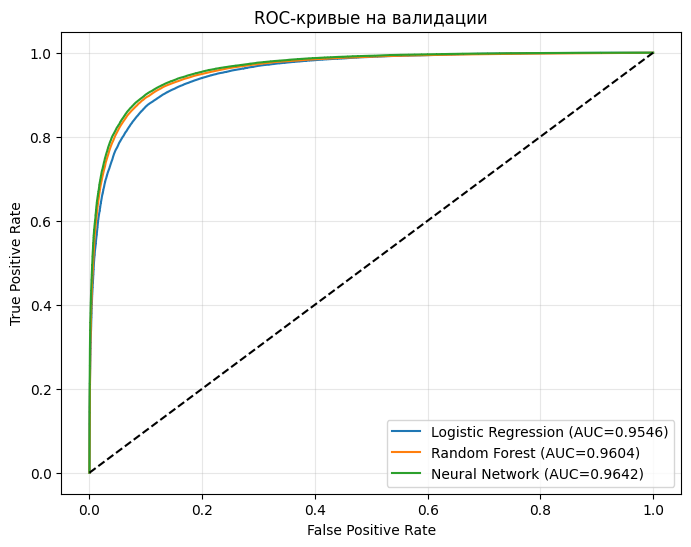

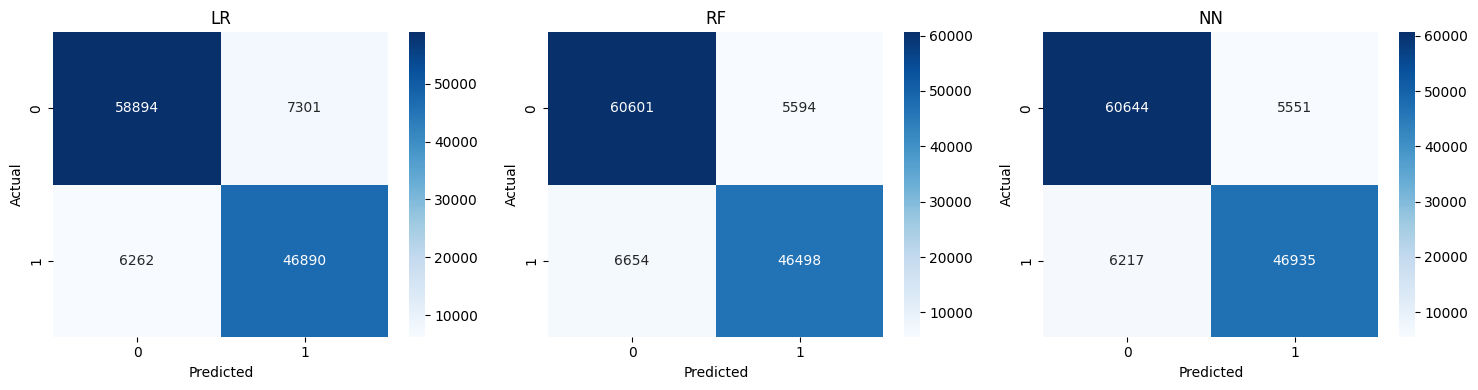


Модели и scaler сохранены.

=== Предсказания на test.csv ===
Первые 20 предсказаний: [1 1 0 0 0 1 1 0 1 0 1 1 1 0 1 0 1 1 1 0]
Первые 20 вероятностей: [0.98996556 0.98132616 0.01375288 0.13639194 0.03547912 0.97548956
 0.96197    0.00391218 0.9303552  0.10998996 0.99267924 0.93934166
 0.99403936 0.22272517 0.84802544 0.1526724  0.64400524 0.89895463
 0.99825126 0.02379531]
Предсказания сохранены в submission.csv

=== Пример инференса ===
Предсказание нейросетью: класс 0, вероятность 0.0039

Готово.


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split  # <--- добавить импорт
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
import joblib

# ==================== ПОДГОТОВКА ДАННЫХ ====================
# Предполагается, что у вас уже есть:
# train_encoded, test_encoded (DataFrame после one-hot)
# Целевая переменная называется 'class'

target_col = 'class'

# Разделяем train_encoded на обучение и валидацию (80%/20%)
X_full = train_encoded.drop(columns=[target_col])
y_full = train_encoded[target_col]

X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full
)

print("Размеры после разделения:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")

# Для инференса используем test_encoded (там нет целевой или она не нужна)
X_test = test_encoded  # если в test_encoded есть столбец class, его нужно удалить, но обычно его нет
if target_col in X_test.columns:
    X_test = X_test.drop(columns=[target_col])

print(f"X_test (для инференса): {X_test.shape}")

# Масштабирование (только для LR и NN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# ==================== 1. ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ ====================
print("\n=== Logistic Regression (balanced) ===")
lr_model = LogisticRegression(
    max_iter=2000,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced',
    solver='saga'
)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_val_scaled)
y_proba_lr = lr_model.predict_proba(X_val_scaled)[:, 1]

lr_metrics = {
    'Accuracy': accuracy_score(y_val, y_pred_lr),
    'Precision': precision_score(y_val, y_pred_lr),
    'Recall': recall_score(y_val, y_pred_lr),
    'F1': f1_score(y_val, y_pred_lr),
    'ROC_AUC': roc_auc_score(y_val, y_proba_lr)
}
print("Метрики на валидации:", lr_metrics)

# ==================== 2. RANDOM FOREST ====================
print("\n=== Random Forest ===")
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)   # масштабирование не нужно
y_pred_rf = rf_model.predict(X_val)
y_proba_rf = rf_model.predict_proba(X_val)[:, 1]

rf_metrics = {
    'Accuracy': accuracy_score(y_val, y_pred_rf),
    'Precision': precision_score(y_val, y_pred_rf),
    'Recall': recall_score(y_val, y_pred_rf),
    'F1': f1_score(y_val, y_pred_rf),
    'ROC_AUC': roc_auc_score(y_val, y_proba_rf)
}
print("Метрики на валидации:", rf_metrics)

# ==================== 3. ГЛУБОКАЯ НЕЙРОННАЯ СЕТЬ ====================
print("\n=== Neural Network ===")
nn_model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

nn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6)

history = nn_model.fit(
    X_train_scaled, y_train,
    validation_split=0.1,   # 10% от X_train для внутренней валидации
    epochs=100,
    batch_size=256,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

y_proba_nn = nn_model.predict(X_val_scaled, verbose=0).flatten()
y_pred_nn = (y_proba_nn >= 0.5).astype(int)

nn_metrics = {
    'Accuracy': accuracy_score(y_val, y_pred_nn),
    'Precision': precision_score(y_val, y_pred_nn),
    'Recall': recall_score(y_val, y_pred_nn),
    'F1': f1_score(y_val, y_pred_nn),
    'ROC_AUC': roc_auc_score(y_val, y_proba_nn)
}
print("Метрики на валидации:", nn_metrics)

# ==================== ГРАФИКИ ОБУЧЕНИЯ НЕЙРОННОЙ СЕТИ ====================
plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(history.history['auc'], label='Train AUC')
plt.plot(history.history['val_auc'], label='Val AUC')
plt.title('AUC')
plt.xlabel('Epoch')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ==================== СРАВНЕНИЕ МОДЕЛЕЙ НА ВАЛИДАЦИИ ====================
metrics_df = pd.DataFrame({
    'Logistic Regression': lr_metrics,
    'Random Forest': rf_metrics,
    'Neural Network': nn_metrics
}).T
print("\n=== Сравнение моделей на валидационной выборке ===")
print(metrics_df.round(4))

# ROC-кривые
plt.figure(figsize=(8,6))
for name, proba in [('Logistic Regression', y_proba_lr),
                    ('Random Forest', y_proba_rf),
                    ('Neural Network', y_proba_nn)]:
    fpr, tpr, _ = roc_curve(y_val, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_val, proba):.4f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые на валидации')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Матрицы ошибок
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for i, (name, y_pred) in enumerate([('LR', y_pred_lr), ('RF', y_pred_rf), ('NN', y_pred_nn)]):
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()

# ==================== СОХРАНЕНИЕ МОДЕЛЕЙ И SCALER ====================
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(lr_model, 'logistic_regression.pkl')
joblib.dump(rf_model, 'random_forest.pkl')
nn_model.save('neural_network.h5')
print("\nМодели и scaler сохранены.")

# ==================== СКРИПТ ДЛЯ ИНФЕРЕНСА (используем X_test_scaled) ====================
class HeartDiseaseInference:
    def __init__(self, scaler, feature_names, lr_model, rf_model, nn_model):
        self.scaler = scaler
        self.feature_names = feature_names
        self.lr = lr_model
        self.rf = rf_model
        self.nn = nn_model
        self.categorical_cols = ['sex', 'resting_electrocardiographic_results', 'thal', 'chest', 'slope', 'exercise_induced_angina']

    def _one_hot(self, df):
        df = pd.get_dummies(df, columns=self.categorical_cols, drop_first=True)
        for col in self.feature_names:
            if col not in df.columns:
                df[col] = 0
        df = df[self.feature_names]
        return df

    def preprocess(self, input_data):
        if isinstance(input_data, dict):
            input_data = pd.DataFrame([input_data])
        encoded = self._one_hot(input_data)
        scaled = self.scaler.transform(encoded)
        return scaled

    def predict(self, input_data, model_name='logistic_regression'):
        X = self.preprocess(input_data)
        if model_name == 'logistic_regression':
            pred = self.lr.predict(X)
            proba = self.lr.predict_proba(X)[:, 1]
        elif model_name == 'random_forest':
            pred = self.rf.predict(X)
            proba = self.rf.predict_proba(X)[:, 1]
        elif model_name == 'neural_network':
            proba = self.nn.predict(X, verbose=0).flatten()
            pred = (proba >= 0.5).astype(int)
        else:
            raise ValueError("model_name должно быть logistic_regression, random_forest или neural_network")
        return pred, proba

feature_names = X_train.columns.tolist()
with open('feature_names.txt', 'w') as f:
    for name in feature_names:
        f.write(name + '\n')

inference = HeartDiseaseInference(scaler, feature_names, lr_model, rf_model, nn_model)

# Предсказания на test.csv (используем уже масштабированный X_test_scaled, но класс ожидает сырые данные.
# Для простоты сделаем предсказание прямо через обученные модели, минуя класс.
print("\n=== Предсказания на test.csv ===")
# Так как X_test_scaled уже подготовлен, просто используем нейросеть:
pred_test = (nn_model.predict(X_test_scaled, verbose=0).flatten() >= 0.5).astype(int)
proba_test = nn_model.predict(X_test_scaled, verbose=0).flatten()
print(f"Первые 20 предсказаний: {pred_test[:20]}")
print(f"Первые 20 вероятностей: {proba_test[:20]}")

# Сохраняем предсказания
submission = pd.DataFrame({
    'ID': range(len(pred_test)),
    'Predicted': pred_test,
    'Probability': proba_test
})
submission.to_csv('submission.csv', index=False)
print("Предсказания сохранены в submission.csv")

# Демонстрация на одном примере
sample = pd.DataFrame([{
    'age': 55,
    'sex': 1,
    'chest': 4,
    'resting_blood_pressure': 140,
    'serum_cholestoral': 250,
    'fasting_blood_sugar': 0,
    'resting_electrocardiographic_results': 1,
    'maximum_heart_rate_achieved': 150,
    'exercise_induced_angina': 0,
    'oldpeak': 1.2,
    'slope': 2,
    'number_of_major_vessels': 0,
    'thal': 3
}])
pred, proba = inference.predict(sample, model_name='neural_network')
print("\n=== Пример инференса ===")
print(f"Предсказание нейросетью: класс {pred[0]}, вероятность {proba[0]:.4f}")

print("\nГотово.")